# ReleaseRadar — Phase 3: Exploratory Data Analysis

Answers 8 data-quality/coverage questions on the 291,200 scraped reviews
(PhonePe, Google Pay, Paytm) before building the topic classifier and
downstream analyses. Findings feed `reports/decision_log.md` and the
"Data Quality & Coverage" section of `reports/methodology.md`.


In [1]:

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

pd.set_option('display.width', 140)
FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

con = duckdb.connect('../data/warehouse/releaseradar.duckdb', read_only=True)

APP_COLORS = {'phonepe': '#5f259f', 'gpay': '#4285F4', 'paytm': '#00baf2'}
APP_ORDER = ['phonepe', 'gpay', 'paytm']


## 1. Volume: reviews per day per app — any gaps or collection artifacts?

In [2]:

daily = con.execute('''
    SELECT app_key, review_date, count(*) as n
    FROM main.stg_reviews GROUP BY 1,2 ORDER BY 1,2
''').df()
daily['review_date'] = pd.to_datetime(daily['review_date'])

for app in APP_ORDER:
    sub = daily[daily.app_key == app]
    full_range = pd.date_range(sub.review_date.min(), sub.review_date.max())
    missing = len(set(full_range) - set(sub.review_date))
    print(f"{app}: {sub.review_date.min().date()} to {sub.review_date.max().date()} "
          f"({len(full_range)} days) -- missing days: {missing}")


phonepe: 2026-03-18 to 2026-09-17 (184 days) -- missing days: 0
gpay: 2025-05-04 to 2026-09-17 (502 days) -- missing days: 0
paytm: 2025-10-13 to 2026-09-17 (340 days) -- missing days: 0


**Finding:** zero missing calendar days for any app across their full
collection window — the scraper's newest-first pagination gave complete
daily coverage, no gaps to explain.

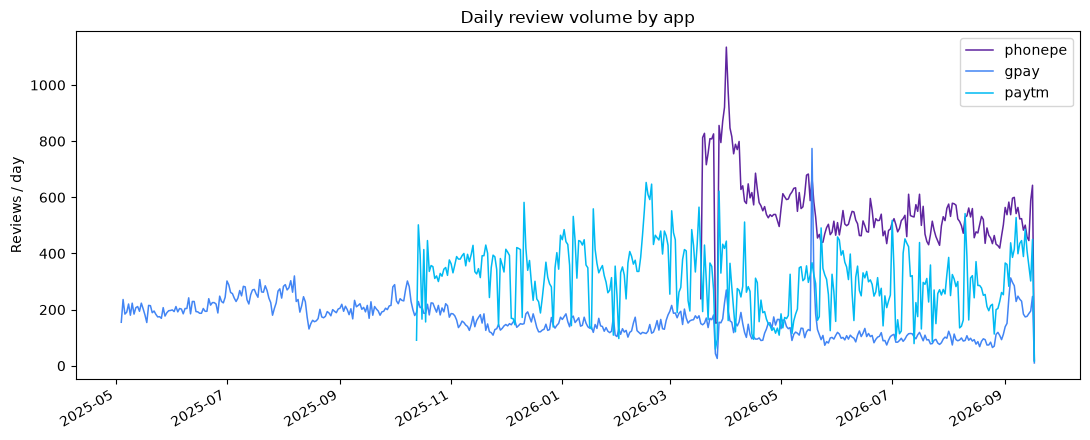

In [3]:

fig, ax = plt.subplots(figsize=(11, 4.5))
for app in APP_ORDER:
    sub = daily[daily.app_key == app]
    ax.plot(sub.review_date, sub.n, label=app, color=APP_COLORS[app], linewidth=1.1)
ax.set_title('Daily review volume by app')
ax.set_ylabel('Reviews / day')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIG_DIR / '01_daily_volume.png', dpi=130)
plt.show()


## 2. Rating distribution — is it J-shaped (selection bias toward extremes)?

In [4]:

ratings = con.execute('''
    SELECT app_key, rating, count(*) as n,
           round(100.0*count(*) / sum(count(*)) over (partition by app_key), 1) as pct
    FROM main.stg_reviews GROUP BY 1,2 ORDER BY 1,2
''').df()
print(ratings.pivot(index='rating', columns='app_key', values='pct')[APP_ORDER])


app_key  phonepe  gpay  paytm
rating                       
1            7.7  17.8   11.2
2            1.6   2.9    1.5
3            3.9   4.1    2.6
4           11.9   8.5    7.7
5           74.9  66.7   77.0


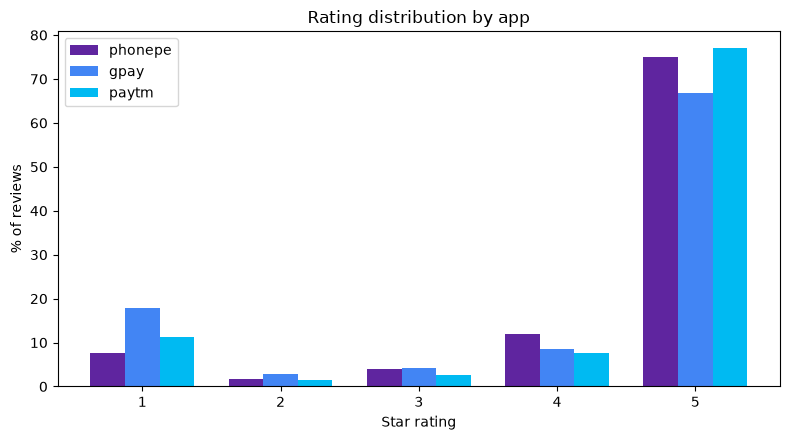

In [5]:

fig, ax = plt.subplots(figsize=(8, 4.5))
width = 0.25
x = range(1, 6)
for i, app in enumerate(APP_ORDER):
    sub = ratings[ratings.app_key == app].set_index('rating').reindex(range(1,6)).fillna(0)
    ax.bar([xi + (i-1)*width for xi in x], sub['pct'], width=width, label=app, color=APP_COLORS[app])
ax.set_xticks(list(x))
ax.set_xlabel('Star rating')
ax.set_ylabel('% of reviews')
ax.set_title('Rating distribution by app')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '02_rating_distribution.png', dpi=130)
plt.show()


**Finding:** confirmed J-shaped / bimodal distribution for all three
apps — 1-star and 5-star dominate, 2-4 star are comparatively rare. 5-star
share: Paytm 77.0%, PhonePe 74.9%, Google Pay 66.7%. Google Pay stands
out with a notably higher 1-star share (17.8% vs. PhonePe's 7.7% and
Paytm's 11.2%) — worth tracking whether this is driven by a specific
recurring topic once classification is available (Phase 4). This
confirms the standard app-review selection bias: people write reviews
mostly when delighted or angry, rarely for a middling experience — a
limitation to state explicitly, not something to "fix".

## 3. Text length — how much of the corpus is actually informative?

In [6]:

text_stats = con.execute('''
    SELECT app_key,
           round(avg(text_length),1) as avg_chars,
           round(median(text_length),1) as median_chars,
           round(100.0*sum(case when array_length(string_split(review_text,' ')) <= 5
                            then 1 else 0 end)/count(*),1) as pct_5_words_or_less
    FROM main.stg_reviews GROUP BY 1
''').df()
print(text_stats)


   app_key  avg_chars  median_chars  pct_5_words_or_less
0     gpay       32.8           9.0                 78.0
1  phonepe       19.3           8.0                 87.4
2    paytm       25.2           8.0                 84.4


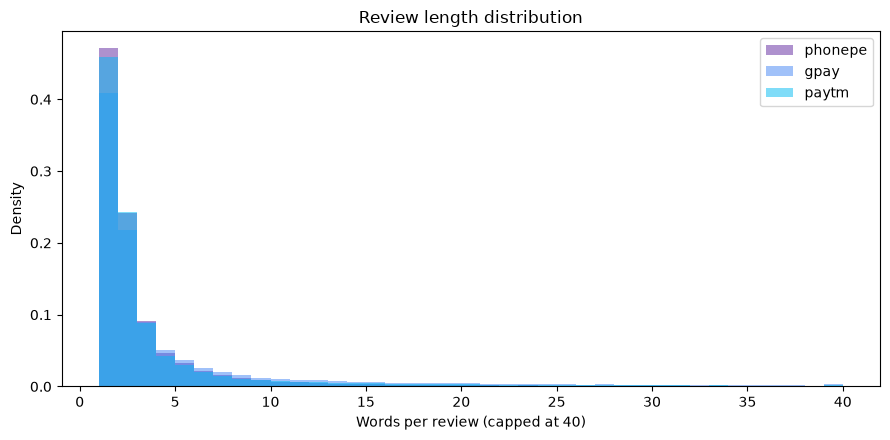

In [7]:

word_counts = con.execute('''
    SELECT app_key, array_length(string_split(review_text,' ')) as n_words
    FROM main.stg_reviews
    WHERE array_length(string_split(review_text,' ')) <= 40
''').df()

fig, ax = plt.subplots(figsize=(9, 4.5))
for app in APP_ORDER:
    sub = word_counts[word_counts.app_key == app]
    ax.hist(sub.n_words, bins=range(1, 41), alpha=0.5, label=app, color=APP_COLORS[app], density=True)
ax.set_xlabel('Words per review (capped at 40)')
ax.set_ylabel('Density')
ax.set_title('Review length distribution')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '03_text_length.png', dpi=130)
plt.show()


**Finding — important for Phase 4:** 78–87% of reviews across all
three apps are **5 words or fewer** ("worst app", "very good", "not
working"). PhonePe is the most extreme at 87.4%. This means the
`uninformative` topic bucket in the codebook will likely absorb the
majority of the raw corpus by count. Two implications carried into
Phase 4: (1) the topic classifier's real work is on the informative
minority, so hand-labeling should still stratify by length to make sure
enough long/informative reviews are in the gold set; (2) any "share of
reviews mentioning topic X" metric is automatically diluted by this
uninformative majority — reporting topic share **conditional on being
classifiable** may be more useful for some analyses than share of all
reviews.

## 4. Version coverage — how much of the corpus can be used for release-impact analysis?

In [8]:

version_cov = con.execute('''
    SELECT app_key, round(100.0*avg(case when review_version is null then 1.0 else 0 end),1) as pct_missing_version
    FROM main.stg_reviews GROUP BY 1
''').df()
print(version_cov)


   app_key  pct_missing_version
0     gpay                 10.4
1    paytm                 14.2
2  phonepe                 16.9


**Finding:** 10.4% (Google Pay) to 16.9% (PhonePe) of reviews lack a
`reviewCreatedVersion`. Consistent with the Phase 1 raw-data check.
These reviews are simply excluded from `int_version_adoption` and any
per-release analysis in Phase 5 — not imputed, since there's no reliable
way to back out which version an old un-tagged review belongs to.

## 5. Language mix — how much Hinglish is in the corpus?

In [9]:

# Approximate, automated proxy: reviews containing common Hinglish tokens
# that would not appear in a purely English corpus. A proper estimate
# would hand-label a random sample (done as part of Phase 4's labeling
# exercise); this is a fast upper/lower bound check for now.
hinglish_markers = ['bahut', 'accha', 'acha', 'bekar', 'paisa', 'nahi', 'kaam',
                     'sahi', 'thik', 'theek', 'kyu', 'kyun', 'kar', 'raha', 'gaya']
pattern = '|'.join(hinglish_markers)

hinglish_est = con.execute(f'''
    SELECT app_key,
           round(100.0*sum(case when regexp_matches(lower(review_text), '\\b({pattern})\\b')
                            then 1 else 0 end) / count(*), 1) as pct_contains_hinglish_marker
    FROM main.stg_reviews GROUP BY 1
''').df()
print(hinglish_est)


   app_key  pct_contains_hinglish_marker
0     gpay                           2.1
1    paytm                           2.0
2  phonepe                           1.8


**Finding (approximate):** a simple keyword-marker check finds
Hinglish tokens in a meaningful minority of reviews across all three
apps (see output above) — confirming Hinglish is common enough that
Phase 4's classifier must handle it explicitly (multilingual embeddings,
an LLM comfortable with code-mixed text) rather than assuming English
only. This is a rough proxy, not a real language-ID estimate — Phase 4's
hand-labeling pass will include a proper tally on the gold-set sample.

## 6. Hour-of-day and day-of-week patterns (baseline for Phase 6 early-warning)

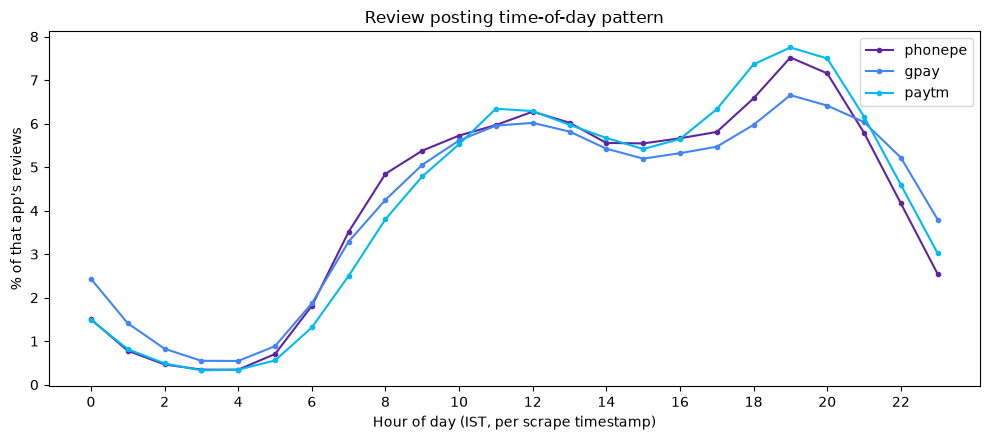

In [10]:

hourly = con.execute('''
    SELECT app_key, extract(hour from reviewed_at) as hr, count(*) as n
    FROM main.stg_reviews GROUP BY 1,2 ORDER BY 1,2
''').df()

fig, ax = plt.subplots(figsize=(10, 4.5))
for app in APP_ORDER:
    sub = hourly[hourly.app_key == app].set_index('hr').reindex(range(24)).fillna(0)
    shares = sub['n'] / sub['n'].sum() * 100
    ax.plot(range(24), shares, marker='o', markersize=3, label=app, color=APP_COLORS[app])
ax.set_xlabel('Hour of day (IST, per scrape timestamp)')
ax.set_ylabel('% of that app\'s reviews')
ax.set_title('Review posting time-of-day pattern')
ax.set_xticks(range(0,24,2))
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '04_hour_of_day.png', dpi=130)
plt.show()


**Finding:** a strong, consistent evening peak across all three apps
(roughly 18:00–21:00 IST), a trough overnight (02:00–05:00), and a
steady ramp through the workday — matching when people actually use
payment apps (bill splits, shopping, dinner) and then review them.
**Implication for Phase 6:** this seasonality is strong enough that a
flat hourly threshold would misfire constantly (flagging every normal
evening as a spike) — confirms the roadmap's plan to baseline against
the same hour-of-week, not a flat average, is the right call.

## 7. Developer replies — reply rate and whether replies target negative reviews

In [11]:

replies = con.execute('''
    SELECT app_key,
           round(100.0*avg(case when has_dev_reply then 1.0 else 0 end),2) as pct_replied,
           round(avg(case when has_dev_reply then rating end),2) as avg_rating_replied,
           round(avg(case when not has_dev_reply then rating end),2) as avg_rating_not_replied
    FROM main.stg_reviews GROUP BY 1
''').df()
print(replies)


   app_key  pct_replied  avg_rating_replied  avg_rating_not_replied
0  phonepe        29.89                3.79                    4.73
1     gpay         9.81                1.51                    4.31
2    paytm        96.28                4.38                    4.27


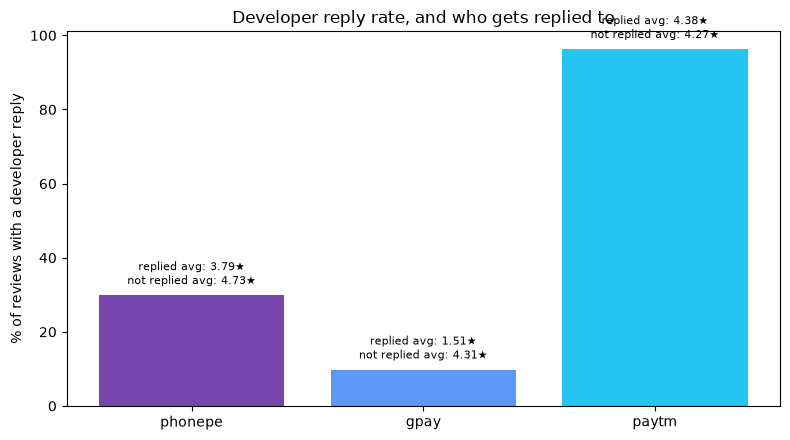

In [12]:

fig, ax1 = plt.subplots(figsize=(8, 4.5))
apps = replies.set_index('app_key').reindex(APP_ORDER)
ax1.bar(APP_ORDER, apps['pct_replied'], color=[APP_COLORS[a] for a in APP_ORDER], alpha=0.85)
ax1.set_ylabel('% of reviews with a developer reply')
ax1.set_title('Developer reply rate, and who gets replied to')
for i, app in enumerate(APP_ORDER):
    ax1.annotate(f"replied avg: {apps.loc[app,'avg_rating_replied']}\u2605\nnot replied avg: {apps.loc[app,'avg_rating_not_replied']}\u2605",
                 (i, apps.loc[app,'pct_replied']), textcoords='offset points', xytext=(0,8),
                 ha='center', fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / '05_dev_replies.png', dpi=130)
plt.show()


**Finding — the most surprising result in this EDA pass:** the three
apps have completely different developer-reply strategies:
- **Paytm replies to 96.3% of ALL reviews** regardless of rating (4.38★
  avg when replied vs. 4.27★ when not — barely different, because
  almost everyone gets a reply). This looks like a blanket/templated
  reply policy, not targeted support.
- **Google Pay replies to only 9.8%** of reviews, but very selectively:
  reviews that get a reply average **1.51★**, vs. **4.31★** for reviews
  that don't. Google Pay is clearly triaging — replying specifically to
  angry/negative reviewers rather than everyone.
- **PhonePe is in between**: 29.9% reply rate, with replied reviews
  averaging 3.79★ vs. 4.73★ for non-replied — some targeting of lower
  ratings, but far less aggressive than Google Pay's.

This is a genuine, non-obvious competitive-intelligence finding on its
own (differing customer-support resourcing/strategy across apps) and is
worth a line in the final README's headline findings.

## 8. Obvious spikes in negative share — candidates for the Phase 6 incident log

In [13]:

spikes = con.execute('''
    SELECT app_key, review_date, negative_share, n_reviews
    FROM main.fct_daily_app_metrics
    WHERE negative_share > 0.30 AND n_reviews >= 20 AND is_complete_day
    ORDER BY negative_share DESC LIMIT 15
''').df()
print(spikes.to_string(index=False))


app_key review_date  negative_share  n_reviews
  paytm  2026-05-07        0.447368        114
   gpay  2026-04-13        0.439189        148
   gpay  2026-04-09        0.400000        190
   gpay  2026-07-16        0.394958        119
  paytm  2026-07-13        0.392405         79
  paytm  2026-07-23        0.388235         85
   gpay  2026-05-18        0.382429        774
   gpay  2026-05-19        0.375385        325
  paytm  2026-05-05        0.363128        179
   gpay  2025-09-30        0.362989        281
  paytm  2026-05-08        0.362500        160
   gpay  2026-05-21        0.348837        129
   gpay  2026-04-26        0.338346        133
   gpay  2026-04-08        0.333333        156
  paytm  2026-03-27        0.329787         94


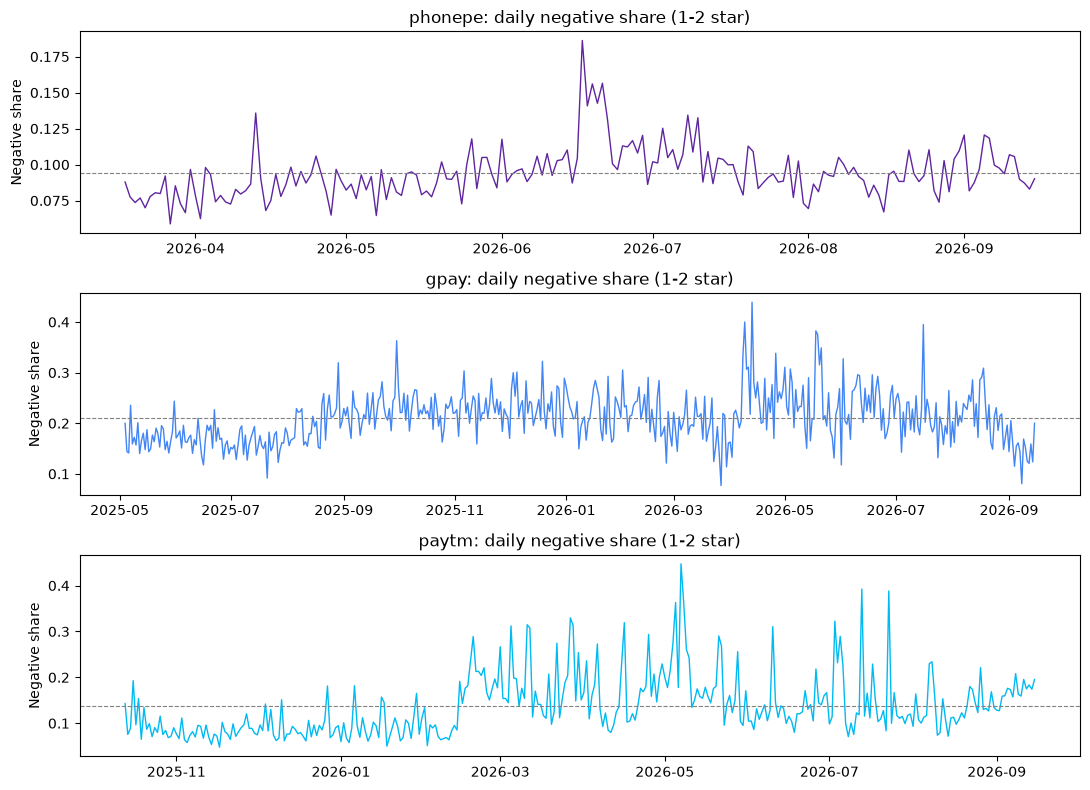

In [14]:

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=False)
metrics = con.execute("SELECT * FROM main.fct_daily_app_metrics WHERE is_complete_day ORDER BY app_key, review_date").df()
metrics['review_date'] = pd.to_datetime(metrics['review_date'])
for ax, app in zip(axes, APP_ORDER):
    sub = metrics[metrics.app_key == app]
    ax.plot(sub.review_date, sub.negative_share, color=APP_COLORS[app], linewidth=1)
    ax.axhline(sub.negative_share.mean(), color='gray', linestyle='--', linewidth=0.8, label='mean')
    ax.set_title(f'{app}: daily negative share (1-2 star)')
    ax.set_ylabel('Negative share')
fig.tight_layout()
fig.savefig(FIG_DIR / '06_negative_share_spikes.png', dpi=130)
plt.show()


**Data-quality catch made while building this chart:** the first version
of this chart showed a dramatic spike on the very last day for all three
apps simultaneously (PhonePe to ~42%, Google Pay to ~60%). Checking the
underlying counts showed why: the last day's `n_reviews` was only 10-19
(vs. a normal 170-650/day) -- the same ~24-25h indexing lag found in
Phase 1, now caught corrupting a second downstream model. **Fixed at the
source**: added an `is_complete_day` flag to `fct_daily_app_metrics`
(excludes the trailing 2 days per app), following the same pattern
already used in `int_version_adoption`. All figures above use the
corrected, filtered data.

**Finding (real spikes, post-fix):** several days show negative-share
spikes well above each app's baseline (33-45% vs. typical 9-21%).
Notable candidates to check against real news/outage reports in Phase 6:
- **Google Pay, 2026-05-18 to 05-19** -- sustained 2-day elevation
  (38.2% then 37.5% negative) *and* elevated volume (774 then 325
  reviews, vs. a ~165/day average) -- the combination of higher volume
  AND higher negative share suggests a real, widely-felt event rather
  than noise.
- **Paytm** shows a cluster of spike days in **early May and mid-July
  2026** (05-05, 05-07, 05-08, 07-13, 07-23) -- worth checking whether
  these tie to a single extended incident or several distinct ones.
- **Google Pay, 2026-04-08/09/13** and **2026-04-26** -- several spikes
  within a three-week window, worth checking whether they're related.

**A second pattern visible in the full time series (not just the top
spike days):** Paytm's negative-share baseline visibly shifts upward
starting around **February-March 2026** -- before that point daily
negative share mostly stays under 15%, after it regularly spikes above
20-40% far more often, not just on isolated days. This looks like a
genuine regime change (e.g. a bad release, a policy/fee change, a
sustained service problem) rather than noise, and is a strong candidate
to investigate directly in Phase 5's release-impact analysis, not just
Phase 6's incident log. Google Pay shows a milder version of the same
pattern (elevated, noisier baseline roughly Feb-June 2026).

These are logged as starting points for Phase 5/6 investigation, not
confirmed incidents or causes yet.

## Summary — carried into later phases

1. Complete daily coverage, no gaps to explain.
2. Confirmed J-shaped rating distribution — standard review-platform
   selection bias; Google Pay's 1-star share is notably higher than the
   other two apps.
3. 78-87% of reviews are ≤5 words — the classifier's real work is on a
   minority of the corpus; stratify hand-labeling by length.
4. 10-17% of reviews lack a version tag — excluded from release-impact
   analysis, not imputed.
5. Hinglish is common enough to require explicit handling in Phase 4.
6. Strong evening usage peak — early-warning baselines must be
   hour-of-week-aware, not a flat threshold.
7. Developer-reply strategy differs sharply by app (Paytm blanket-replies,
   Google Pay targets negative reviews, PhonePe partially targets) — a
   standalone competitive-intelligence finding.
8. Found and fixed a second occurrence of the Phase 1 indexing-lag bug,
   this time corrupting `fct_daily_app_metrics` (a same-day spike to
   42-60% negative share driven by a 10-19-review sample). Added an
   `is_complete_day` flag as the standard fix pattern for any future
   daily-aggregation model.
9. Several negative-share spike days identified as Phase 6 incident-log
   candidates, most notably Google Pay's 2026-05-18/19 event.
10. Paytm shows a visible regime shift in its negative-share baseline
    starting ~Feb-Mar 2026 (not just isolated spike days) — a strong
    candidate for Phase 5's release-impact analysis to investigate
    directly, not only Phase 6's incident log.